# Clasificación de sentimientos mediante TF-IDF y SVM lineal

## 1. Introducción

En este notebook se desarrolla un clasificador de sentimientos basado en Máquinas de Soporte Vectorial con kernel lineal (`LinearSVC`), como parte de la comparación de modelos clásicos realizada por el equipo para la Parte 1 de la competencia.

El punto de partida es la mejor representación encontrada en el notebook de Regresión Logística (modelo V2): la última oración de cada reseña representada mediante TF-IDF de palabras (unigramas y bigramas) y de caracteres (secuencias de tres a cinco caracteres). Esa configuración obtuvo una accuracy promedio de 85,36% en validación cruzada y un puntaje público de 86,56% en Kaggle.

Una SVM lineal busca el hiperplano que separa las clases con el mayor margen posible. Este tipo de modelo suele funcionar bien con representaciones de texto dispersas y de alta dimensionalidad como TF-IDF, ya que en esos espacios las clases tienden a ser aproximadamente separables de forma lineal. Para el caso multiclase, `LinearSVC` entrena un clasificador por clase (esquema uno contra el resto).

El desarrollo seguirá la misma estructura de las prácticas del curso: carga y partición de los datos, construcción del pipeline, búsqueda de hiperparámetros con validación cruzada, evaluación, análisis de errores, persistencia del modelo y generación de predicciones para Kaggle.

Para que los resultados sean comparables con los demás modelos del equipo se mantiene la misma partición estratificada (80% entrenamiento, 20% validación, `random_state=42`) y la misma estrategia de validación cruzada estratificada de cinco particiones.

## 2. Importación de librerías

Se utilizarán pandas y NumPy para el manejo de datos y Matplotlib para las visualizaciones.

De scikit-learn se emplearán `TfidfVectorizer` para la representación de texto, `FeatureUnion` para combinar varias representaciones, `FunctionTransformer` para incorporar las transformaciones propias del texto dentro del pipeline y `LinearSVC` como clasificador. La búsqueda de hiperparámetros se realizará con `GridSearchCV` y `StratifiedKFold`.

Las funciones de transformación del texto se encuentran en el módulo `transformaciones.py` de la raíz del proyecto. Mantenerlas en un módulo, y no definidas dentro del notebook, permite que el pipeline almacenado con `joblib` pueda cargarse posteriormente desde cualquier entorno que tenga acceso a ese archivo.

In [1]:
import sys
import importlib
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_val_predict
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import FunctionTransformer
from sklearn.svm import LinearSVC
from sklearn.base import clone

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Identificar la carpeta del proyecto
raiz = Path.cwd().resolve()

if raiz.name == "notebooks":
    raiz = raiz.parent

if str(raiz) not in sys.path:
    sys.path.insert(0, str(raiz))

# Importar las transformaciones del proyecto
import transformaciones
importlib.reload(transformaciones)

from transformaciones import (
    extraer_oraciones_lote,
    marcar_conectores_lote,
    segmentar_clausulas,
    marcar_clausulas_lote
)

print("Librerías y transformaciones importadas correctamente")

Librerías y transformaciones importadas correctamente


## 3. Carga y partición de los datos

Se utilizará el conjunto de entrenamiento de la competencia, con 12.000 reseñas etiquetadas como positivas, negativas o neutrales, y el conjunto de evaluación de Kaggle, con 3.000 reseñas sin etiqueta.

La partición se realiza de forma estratificada y con la misma semilla aleatoria empleada por el equipo, de manera que los 2.400 registros de validación sean exactamente los mismos que se utilizaron para evaluar los demás modelos.

El conjunto de evaluación de Kaggle no se utilizará para entrenar ni para seleccionar hiperparámetros. Solo se empleará al final para generar las predicciones del envío.

In [2]:
# Ubicación de los archivos
data_dir = raiz / "data"

# Cargar los datos
train = pd.read_csv(data_dir / "train.csv")
eval_data = pd.read_csv(data_dir / "eval.csv")
sample = pd.read_csv(data_dir / "sample_submission.csv")

# Separar variables
X = train["text"]
y = train["label"]

# División de entrenamiento y validación
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Datos de entrenamiento:", len(X_train))
print("Datos de validación:", len(X_val))
print("Datos de evaluación (Kaggle):", len(eval_data))

print("\nDistribución en entrenamiento:")
print(y_train.value_counts(normalize=True).round(3))

Datos de entrenamiento: 9600
Datos de validación: 2400
Datos de evaluación (Kaggle): 3000

Distribución en entrenamiento:
label
positivo    0.351
negativo    0.351
neutral     0.298
Name: proportion, dtype: float64


## 4. Modelo base: SVM lineal con la representación V2

Como primer experimento se reemplaza la Regresión Logística del modelo V2 por una SVM lineal, manteniendo exactamente la misma representación del texto:

1. Extracción de la última oración de cada reseña, mediante la función `extraer_oraciones_lote` del módulo de transformaciones.
2. TF-IDF de palabras con unigramas y bigramas, frecuencia documental mínima de 2 y frecuencia sublineal (`sublinear_tf=True`).
3. TF-IDF de caracteres con secuencias de tres a cinco caracteres y los mismos parámetros.

Las dos representaciones se combinan mediante `FeatureUnion`. Así, si hay diferencias de desempeño frente a V2, se deben al clasificador y no a la representación.

El hiperparámetro principal de `LinearSVC` es `C`, que controla la regularización de forma análoga a la Regresión Logística: valores pequeños producen un margen más amplio y un modelo más regularizado, mientras que valores grandes intentan clasificar correctamente más ejemplos de entrenamiento, con mayor riesgo de sobreajuste. Se usa `max_iter=5000` para que el optimizador alcance a converger.

In [3]:
# Representación del modelo V2: última oración, palabras y caracteres
representacion_v2 = FeatureUnion([
    (
        "palabras",
        TfidfVectorizer(
            analyzer="word",
            ngram_range=(1, 2),
            min_df=2,
            sublinear_tf=True
        )
    ),
    (
        "caracteres",
        TfidfVectorizer(
            analyzer="char",
            ngram_range=(3, 5),
            min_df=2,
            sublinear_tf=True
        )
    )
])

pipeline_svm_base = Pipeline([
    (
        "extraer_oracion",
        FunctionTransformer(
            extraer_oraciones_lote,
            kw_args={"cantidad": 1},
            validate=False
        )
    ),
    (
        "representacion",
        representacion_v2
    ),
    (
        "modelo",
        LinearSVC(
            max_iter=5000,
            random_state=42
        )
    )
])

pipeline_svm_base

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('extraer_oracion', ...), ('representacion', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function ext...0025738C045E0>
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to func... versionadded:: 0.18",{'cantidad': 1}
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`f

### 4.1. Búsqueda de hiperparámetros del modelo base

Se realizará una búsqueda mediante `GridSearchCV` sobre dos hiperparámetros:

- `C`: valores entre 0,05 y 1, en una escala que permite observar el efecto de la regularización.
- `class_weight`: sin ponderación (`None`) o con ponderación balanceada (`'balanced'`). En la descripción de la competencia se menciona que la clase `neutral` es algo menos frecuente que `positivo` y `negativo`. Siguiendo lo visto en la práctica de Random Forest, `class_weight='balanced'` asigna a cada clase un peso inversamente proporcional a su frecuencia, sin generar datos sintéticos.

La métrica de selección es la accuracy, por ser la métrica de evaluación de la competencia. Como el desbalance es leve (35%, 35% y 30%), esta métrica no resulta engañosa en este caso. Aun así, se revisará el desempeño por clase en la evaluación.

In [4]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

param_grid_base = {
    "modelo__C": [0.05, 0.1, 0.2, 0.5, 1],
    "modelo__class_weight": [None, "balanced"]
}

grid_base = GridSearchCV(
    estimator=pipeline_svm_base,
    param_grid=param_grid_base,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_base.fit(X_train, y_train)

print("Mejores parámetros:", grid_base.best_params_)
print(f"Accuracy promedio en CV: {grid_base.best_score_:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Mejores parámetros: {'modelo__C': 0.2, 'modelo__class_weight': 'balanced'}
Accuracy promedio en CV: 0.8595


In [5]:
resultados_base = pd.DataFrame(grid_base.cv_results_)

cols = [
    "param_modelo__C",
    "param_modelo__class_weight",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]

display(resultados_base[cols].sort_values("rank_test_score"))

,param_modelo__C,param_modelo__class_weight,mean_test_score,std_test_score,rank_test_score
5,0.20,balanced,0.859479,0.008510,1
4,0.20,NaN,0.859479,0.008561,2
2,0.10,NaN,0.859167,0.008524,3
3,0.10,balanced,0.858958,0.009048,4
7,0.50,balanced,0.858646,0.009332,5
6,0.50,NaN,0.858542,0.009180,6
9,1.00,balanced,0.856250,0.006267,7
8,1.00,NaN,0.855729,0.006839,8
1,0.05,balanced,0.854375,0.011376,9
0,0.05,NaN,0.854063,0.010671,10


### 4.2. Resultados del modelo base

Se evaluaron 10 configuraciones mediante validación cruzada estratificada de cinco particiones, para un total de 50 ajustes.

La mejor configuración utilizó `C=0.2`, con una accuracy promedio de 85,95%. Este resultado supera en aproximadamente 0,6 puntos porcentuales al 85,36% obtenido por la Regresión Logística V2 con la misma representación y las mismas particiones.

La ponderación de clases prácticamente no modificó el desempeño: con `C=0.2`, ambas variantes obtuvieron 85,95%, y en general las diferencias entre `None` y `'balanced'` fueron inferiores a 0,1 puntos porcentuales. Esto es coherente con el desbalance leve del conjunto de datos. La búsqueda seleccionó `class_weight='balanced'`, pero la diferencia con `None` en la accuracy promedio es despreciable.

Respecto a la regularización, los valores intermedios de `C` (0,1 a 0,5) obtuvieron los mejores resultados. Con `C=0.05` el modelo queda demasiado regularizado (85,44%) y con `C=1` el desempeño también disminuye (85,62%), lo que sugiere un inicio de sobreajuste.

## 5. Evaluación del modelo base en validación

Se evaluará el mejor pipeline encontrado sobre las 2.400 reseñas reservadas para validación, que no participaron en el entrenamiento ni en la búsqueda de hiperparámetros.

Accuracy en validación: 0.8729

              precision    recall  f1-score   support

    negativo     0.8384    0.8493    0.8438       843
     neutral     0.9080    0.9804    0.9428       715
    positivo     0.8760    0.8052    0.8391       842

    accuracy                         0.8729      2400
   macro avg     0.8741    0.8783    0.8753      2400
weighted avg     0.8723    0.8729    0.8717      2400



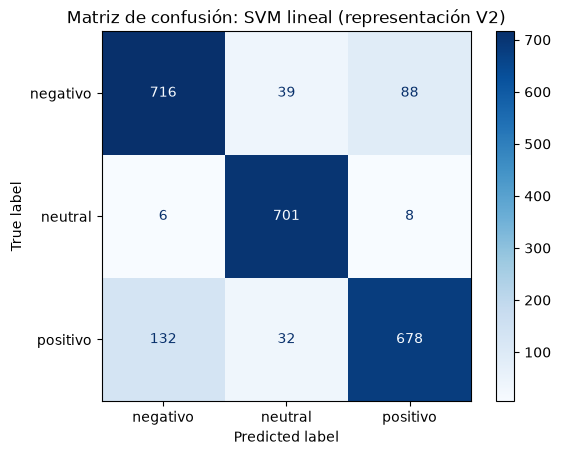

In [6]:
mejor_base = grid_base.best_estimator_

y_pred_base = mejor_base.predict(X_val)

print(f"Accuracy en validación: {accuracy_score(y_val, y_pred_base):.4f}\n")
print(classification_report(y_val, y_pred_base, digits=4))

ConfusionMatrixDisplay.from_predictions(y_val, y_pred_base, cmap="Blues")
plt.title("Matriz de confusión: SVM lineal (representación V2)")
plt.show()

### 5.1. Interpretación de los resultados del modelo base

El modelo base obtuvo una accuracy de 87,29% sobre las 2.400 reseñas de validación, valor cercano al 85,95% de la validación cruzada.

La clase `neutral` es la que mejor se clasifica, con un F1-score de 0,94 y un recall de 0,98. Las clases `negativo` y `positivo` obtuvieron F1-scores de 0,84. Como en los modelos anteriores del equipo, la principal dificultad sigue siendo distinguir entre reseñas positivas y negativas: la mayoría de los errores de la matriz de confusión corresponden a confusiones entre estas dos clases.

## 6. Análisis de errores

Para entender qué limita al modelo, se obtienen predicciones fuera de muestra sobre el conjunto de entrenamiento mediante `cross_val_predict`. Cada reseña se predice con un modelo que no la vio durante el ajuste, por lo que se pueden revisar los errores sin utilizar el conjunto de validación.

In [7]:
pred_cv_base = cross_val_predict(
    mejor_base,
    X_train,
    y_train,
    cv=cv,
    n_jobs=-1
)

errores = pd.DataFrame({
    "text": X_train,
    "real": y_train,
    "predicho": pred_cv_base
})
errores = errores[errores["real"] != errores["predicho"]]

print("Errores en validación cruzada:", len(errores), "de", len(X_train))

display(pd.crosstab(errores["real"], errores["predicho"]))

Errores en validación cruzada: 1349 de 9600


predicho,negativo,neutral,positivo
real,,,
negativo,0,159,436
neutral,14,0,32
positivo,525,183,0


In [8]:
# Muestra de reseñas positivas y negativas confundidas entre sí
pd.set_option("display.max_colwidth", None)

muestra_errores = errores[
    errores["real"].isin(["positivo", "negativo"]) &
    errores["predicho"].isin(["positivo", "negativo"])
].sample(8, random_state=1)

for _, fila in muestra_errores.iterrows():
    print(f"[real={fila['real']} | predicho={fila['predicho']}]")
    print(fila["text"])
    print()

[real=negativo | predicho=positivo]
Me llego el paquete a mitad de semana, dos dias despues de pedirlo, y venia bien embalado con sus manuales y demas. Lo compre para el cuarto de invitados mas que nada, por una mudanza que hicimos en marzo. La app del fabricante me dio mas de un dolor de cabeza, la verdad, y la bateria fue todo un acierto. Cada quien que juzgue.

[real=negativo | predicho=positivo]
Lo compre a mediados de mes por internet y llego en cuatro dias, asi que ahi no hubo problema. Llevo varias semanas usandolo casi a diario y lo estoy probando a fondo en distintas situaciones. El peso se dano antes de lo que esperaba. Por otro lado, recomiendo la relacion calidad-precio con los ojos cerrados.

[real=positivo | predicho=negativo]
Llevo ya un buen rato con esta máquina, la pruebo casi todos los días en la cocina después del trabajo, me llegó a los cuatro días de pedirla. La neta el motor no vale lo que cuesta. Además, me alegra haber elegido el empaque, porque venía bien pues

### 6.1. Interpretación del análisis de errores

Al revisar las reseñas mal clasificadas se observa un patrón que se repite: muchas reseñas tienen dos opiniones opuestas sobre distintos aspectos del producto, y el sentimiento global parece depender de la expresión con la que se introduce cada opinión, no solo de su posición en el texto.

- Expresiones como "Eso sí,", "Por cierto,", "De paso," o "Por otro lado," suelen introducir un comentario secundario. En muchas de estas reseñas el sentimiento global corresponde a la opinión anterior, aunque la secundaria esté más cerca del final.
- Muchas reseñas terminan con frases sin carga de sentimiento ("Cada quien que juzgue", "No sabría bien qué recomendar"). En esos casos la última oración no contiene la opinión que define la etiqueta.
- Estos patrones no se cumplen siempre: también hay reseñas en las que la opinión introducida por uno de estos conectores sí coincide con la etiqueta. Por eso no se escribieron reglas manuales, sino que se le da al modelo esta información para que aprenda su peso a partir de los datos.

Esto explica por qué el modelo que solo observa la última oración falla en las reseñas con opiniones mixtas. Además, coincide con lo que plantea el enunciado del proyecto: el sentimiento global depende del orden y de los conectores contrastivos, y esa información se pierde en una bolsa de palabras convencional.

Para comprobarlo, se compara qué tan frecuentes son algunas de estas expresiones en las reseñas mal clasificadas y en el total.

In [9]:
expresiones = ["eso sí", "por cierto", "de paso", "por otro lado",
               "en cambio", "sin embargo", "al final"]

texto_train = X_train.str.lower()
texto_errores = errores["text"].str.lower()

presencia = pd.DataFrame({
    "Expresión": expresiones,
    "% en todas las reseñas": [texto_train.str.contains(e).mean() * 100 for e in expresiones],
    "% en reseñas mal clasificadas": [texto_errores.str.contains(e).mean() * 100 for e in expresiones]
}).round(2)

display(presencia)

,Expresión,% en todas las reseñas,% en reseñas mal clasificadas
0,eso sí,9.44,11.64
1,por cierto,5.84,7.56
2,de paso,5.29,7.26
3,por otro lado,6.19,14.16
4,en cambio,0.26,0.96
5,sin embargo,1.00,2.15
6,al final,9.91,6.30


### 6.2. Interpretación de la presencia de conectores

Las expresiones que introducen comentarios secundarios están sobrerrepresentadas en las reseñas mal clasificadas. El caso más marcado es "por otro lado", presente en el 6,19% del total de reseñas pero en el 14,16% de los errores, es decir, más del doble. También aumentan "por cierto" (5,84% frente a 7,56%), "de paso" (5,29% frente a 7,26%) y "eso sí" (9,44% frente a 11,64%).

En cambio, "al final" aparece con menor frecuencia en los errores (6,30%) que en el total (9,91%). Una posible explicación es que, cuando la última oración comienza con esta expresión, suele contener la valoración que define la etiqueta, y el modelo base ya se fija en esa oración.

Estos resultados apoyan la hipótesis de que el modelo se equivoca más cuando la reseña tiene un conector que cambia la importancia de las opiniones.

## 7. Representación con conectores y posición de las frases

Para que un modelo lineal pueda aprovechar esta información, se propone una representación adicional que conserve, para cada palabra, el contexto de la frase en la que aparece. La transformación `marcar_conectores_lote` del módulo de transformaciones:

1. Divide la reseña en frases, usando como separadores los signos de fin de oración y el punto y coma.
2. Toma las primeras palabras de cada frase como su conector. El número de palabras es un parámetro (`palabras_conector`): con dos palabras se obtienen marcas como `eso_sí` o `por_cierto`, y con una, marcas como `eso` o `por`.
3. Genera, para cada palabra de la frase, un token compuesto con el conector (`eso_sí__feliz`) y otro con la posición de la frase contada desde el final (`p1__feliz` para la última frase, `p2__feliz` para la penúltima, etc.).

Los conectores no se definen a mano: el modelo aprende de los datos qué combinaciones de conector y palabra son útiles. Por ejemplo, puede aprender que `feliz` empuja hacia `positivo`, pero que `eso_sí__feliz` debe restar parte de ese aporte, porque esa opinión suele ser secundaria.

Los tokens compuestos se representan con TF-IDF, con frecuencia documental mínima de 2 y frecuencia sublineal, igual que las demás representaciones.

Este es el resultado de la transformación sobre un ejemplo, usando dos palabras como conector:

In [10]:
ejemplo = (
    "Lo compré hace un mes y llegó en tres días. "
    "La correa me dio más de un dolor de cabeza. "
    "Eso sí, estoy feliz con el manual."
)

print(marcar_conectores_lote([ejemplo])[0])

lo_compré__lo lo_compré__compré lo_compré__hace lo_compré__un lo_compré__mes lo_compré__y lo_compré__llegó lo_compré__en lo_compré__tres lo_compré__días p3__lo p3__compré p3__hace p3__un p3__mes p3__y p3__llegó p3__en p3__tres p3__días la_correa__la la_correa__correa la_correa__me la_correa__dio la_correa__más la_correa__de la_correa__un la_correa__dolor la_correa__de la_correa__cabeza p2__la p2__correa p2__me p2__dio p2__más p2__de p2__un p2__dolor p2__de p2__cabeza eso_sí__eso eso_sí__sí eso_sí__estoy eso_sí__feliz eso_sí__con eso_sí__el eso_sí__manual p1__eso p1__sí p1__estoy p1__feliz p1__con p1__el p1__manual


La representación final combina, mediante `FeatureUnion`, cuatro bloques:

| Bloque | Entrada | Representación |
|---|---|---|
| `conectores` | Reseña completa marcada con conector y posición | TF-IDF de tokens compuestos |
| `texto_completo` | Reseña completa | TF-IDF de palabras (1-2 gramas) |
| `ultima_palabras` | Última oración | TF-IDF de palabras (1-2 gramas) |
| `ultima_caracteres` | Última oración | TF-IDF de caracteres (3-5) |

Los dos últimos bloques son la representación V2, que sigue siendo la que más información da sobre la valoración final. Los dos primeros agregan el contexto del resto de la reseña.

In [11]:
def ultima_oracion():
    return FunctionTransformer(
        extraer_oraciones_lote,
        kw_args={"cantidad": 1},
        validate=False
    )

representacion_conectores = FeatureUnion([
    (
        "conectores",
        Pipeline([
            (
                "marcar",
                FunctionTransformer(
                    marcar_conectores_lote,
                    kw_args={"palabras_conector": 2},
                    validate=False
                )
            ),
            (
                "tfidf",
                TfidfVectorizer(
                    token_pattern=r"\S+",
                    lowercase=False,
                    min_df=2,
                    sublinear_tf=True
                )
            )
        ])
    ),
    (
        "texto_completo",
        TfidfVectorizer(
            analyzer="word",
            ngram_range=(1, 2),
            min_df=2,
            sublinear_tf=True
        )
    ),
    (
        "ultima_palabras",
        Pipeline([
            ("extraer", ultima_oracion()),
            ("tfidf", TfidfVectorizer(analyzer="word", ngram_range=(1, 2),
                                      min_df=2, sublinear_tf=True))
        ])
    ),
    (
        "ultima_caracteres",
        Pipeline([
            ("extraer", ultima_oracion()),
            ("tfidf", TfidfVectorizer(analyzer="char", ngram_range=(3, 5),
                                      min_df=2, sublinear_tf=True))
        ])
    )
])

pipeline_svm_conectores = Pipeline([
    ("representacion", representacion_conectores),
    ("modelo", LinearSVC(max_iter=5000, random_state=42))
])

pipeline_svm_conectores

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('representacion', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformer_list transformer_list: list of (str, transformer) tuplesList of transformer objects to be applied to the data. The firsthalf of each tuple is the name of the transformer. The transformer canbe 'drop' for it to be ignored or can be 'passthrough' for features tobe passed unchanged... versionadded:: 1.1 Added the option `""passthrough""`... versionchanged:: 0.22 Deprecated `None` as a transformer in favor of 'drop'.","[('conectores', ...), ('texto_completo', ...), ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer.Keys are transformer names, values the weights.Raises ValueError if key not present in ``transformer_list``.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, default=TrueIf True, :meth:`get_feature_names_out` will prefix all feature nameswith the name of the transformer that generated that feature.If False, :meth:`get_feature_names_out` will not prefix any featurenames and will error if feature names are not unique... versionadded:: 1.5",True
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function mar...0025764E97E20>
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to func... versionadded:: 0.18",{'palabras_conector': 2}


### 7.1. Búsqueda de hiperparámetros del modelo con conectores

Se realizará una nueva búsqueda con `GridSearchCV`, utilizando las mismas particiones de validación cruzada. Además de `C`, se prueba si conviene tomar una o dos palabras iniciales como conector.

Como en el modelo base la ponderación balanceada de clases no produjo una mejora relevante, en esta búsqueda se mantiene `class_weight=None`.

In [12]:
param_grid_conectores = {
    "representacion__conectores__marcar__kw_args": [
        {"palabras_conector": 1},
        {"palabras_conector": 2}
    ],
    "modelo__C": [0.1, 0.3, 0.6, 1.0, 1.5]
}

grid_conectores = GridSearchCV(
    estimator=pipeline_svm_conectores,
    param_grid=param_grid_conectores,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_conectores.fit(X_train, y_train)

print("Mejores parámetros:", grid_conectores.best_params_)
print(f"Accuracy promedio en CV: {grid_conectores.best_score_:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Mejores parámetros: {'modelo__C': 0.6, 'representacion__conectores__marcar__kw_args': {'palabras_conector': 1}}
Accuracy promedio en CV: 0.8830


In [13]:
resultados_conectores = pd.DataFrame(grid_conectores.cv_results_)

cols = [
    "param_representacion__conectores__marcar__kw_args",
    "param_modelo__C",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]

display(resultados_conectores[cols].sort_values("rank_test_score"))

,param_representacion__conectores__marcar__kw_args,param_modelo__C,mean_test_score,std_test_score,rank_test_score
4,{'palabras_conector': 1},0.6,0.883021,0.011866,1
3,{'palabras_conector': 2},0.3,0.881875,0.013695,2
2,{'palabras_conector': 1},0.3,0.881771,0.013498,3
5,{'palabras_conector': 2},0.6,0.881562,0.012275,4
7,{'palabras_conector': 2},1.0,0.881146,0.011979,5
6,{'palabras_conector': 1},1.0,0.880729,0.011845,6
8,{'palabras_conector': 1},1.5,0.880521,0.011198,7
0,{'palabras_conector': 1},0.1,0.880208,0.013389,8
9,{'palabras_conector': 2},1.5,0.879583,0.012428,9
1,{'palabras_conector': 2},0.1,0.878438,0.013628,10


### 7.2. Resultados de la búsqueda

Se evaluaron 10 configuraciones, para un total de 50 ajustes.

La mejor configuración utilizó una palabra como conector y `C=0.6`, con una accuracy promedio de 88,30%. Esto representa una mejora de aproximadamente 2,35 puntos porcentuales respecto al modelo base de SVM (85,95%) y de 2,94 puntos respecto a la Regresión Logística V2 (85,36%).

Las diez configuraciones obtuvieron entre 87,84% y 88,30%. Todas superan al modelo base, así que la mejora no depende de una combinación específica de hiperparámetros. La diferencia entre usar una o dos palabras como conector es pequeña (88,30% frente a 88,19%) y queda dentro de la desviación estándar entre particiones (alrededor de 1,2 puntos), así que ambas opciones son equivalentes en la práctica.

Los valores de `C` entre 0,3 y 1,0 producen resultados muy similares, y valores mayores (1,5) no aportan mejoras.

## 8. Evaluación del modelo con conectores en validación

Se evalúa el mejor pipeline sobre las mismas 2.400 reseñas de validación utilizadas para el modelo base.

Accuracy en validación: 0.8871

              precision    recall  f1-score   support

    negativo     0.8380    0.8529    0.8454       843
     neutral     0.9835    0.9986    0.9910       715
    positivo     0.8529    0.8266    0.8396       842

    accuracy                         0.8871      2400
   macro avg     0.8915    0.8927    0.8920      2400
weighted avg     0.8866    0.8871    0.8867      2400



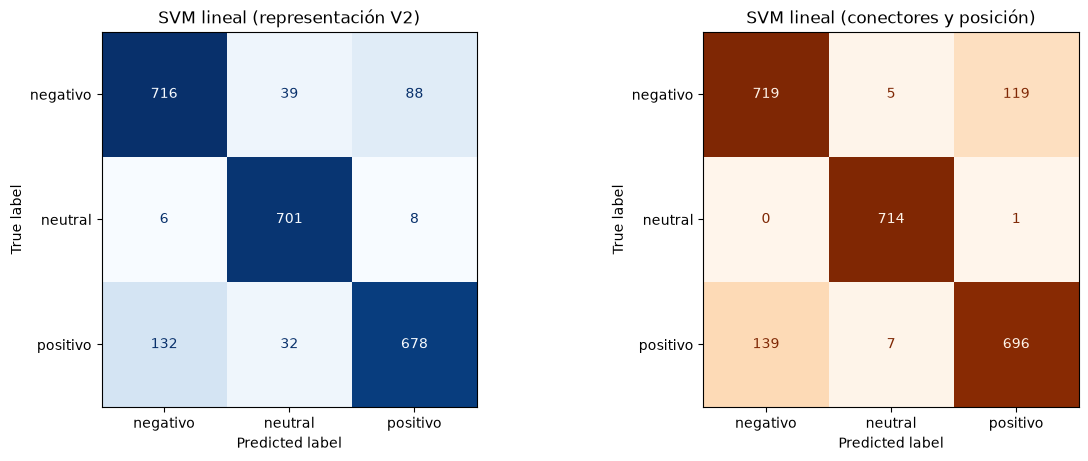

In [14]:
mejor_conectores = grid_conectores.best_estimator_

y_pred_conectores = mejor_conectores.predict(X_val)

print(f"Accuracy en validación: {accuracy_score(y_val, y_pred_conectores):.4f}\n")
print(classification_report(y_val, y_pred_conectores, digits=4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred_base, cmap="Blues", ax=axes[0], colorbar=False
)
axes[0].set_title("SVM lineal (representación V2)")

ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred_conectores, cmap="Oranges", ax=axes[1], colorbar=False
)
axes[1].set_title("SVM lineal (conectores y posición)")

plt.show()

### 8.1. Comparación de los modelos

Se resumen los resultados de los modelos evaluados en este notebook junto con la referencia del modelo V2 de Regresión Logística. Se incluye la accuracy en entrenamiento para revisar posibles señales de sobreajuste, como en las prácticas del curso.

In [15]:
comparacion = pd.DataFrame([
    {
        "Modelo": "Regresión Logística V2 (referencia del equipo)",
        "Accuracy CV": 0.8536,
        "Accuracy entrenamiento": np.nan,
        "Accuracy validación": np.nan
    },
    {
        "Modelo": "SVM lineal (representación V2)",
        "Accuracy CV": grid_base.best_score_,
        "Accuracy entrenamiento": accuracy_score(y_train, mejor_base.predict(X_train)),
        "Accuracy validación": accuracy_score(y_val, y_pred_base)
    },
    {
        "Modelo": "SVM lineal (conectores y posición)",
        "Accuracy CV": grid_conectores.best_score_,
        "Accuracy entrenamiento": accuracy_score(y_train, mejor_conectores.predict(X_train)),
        "Accuracy validación": accuracy_score(y_val, y_pred_conectores)
    }
])

display(comparacion.round(4))

,Modelo,Accuracy CV,Accuracy entrenamiento,Accuracy validación
0,Regresión Logística V2 (referencia del equipo),0.8536,NaN,NaN
1,SVM lineal (representación V2),0.8595,0.9219,0.8729
2,SVM lineal (conectores y posición),0.8830,0.9999,0.8871


### 8.2. Interpretación de la comparación

El modelo con representación de conectores y posición obtuvo una accuracy de 88,71% en validación, frente al 87,29% del modelo base. La mejora que se vio en la validación cruzada se mantiene en datos que no se usaron para elegir los hiperparámetros.

Por clase, la mejora está sobre todo en `neutral`, cuyo F1-score pasa de 0,94 a 0,99. Las clases `negativo` y `positivo` se mantienen en valores similares (0,85 y 0,84). Es decir, mirar el resto de la reseña ayuda principalmente a reconocer cuándo una reseña no tiene una valoración clara. La confusión entre positivo y negativo sigue siendo la principal fuente de error.

La accuracy en entrenamiento del modelo con conectores es prácticamente del 100%, frente al 92,19% del modelo base. Esto indica que el modelo memoriza el conjunto de entrenamiento, lo cual es esperable por la gran cantidad de características que genera la nueva representación. Aun así, en validación cruzada y en validación le va mejor que al modelo base, por lo que esa capacidad extra no está afectando la generalización. Hay que tenerlo en cuenta para el puntaje privado de Kaggle.

## 9. Análisis de las características aprendidas

Al ser un modelo lineal, `LinearSVC` asigna un coeficiente a cada característica para cada clase. Se revisan los tokens compuestos de conector con mayor coeficiente para las clases positiva y negativa, con el fin de verificar si el modelo aprendió patrones coherentes con el análisis de errores.

Como en la práctica de Regresión Logística, los coeficientes deben interpretarse como asociaciones aprendidas por el modelo y no como relaciones causales. Además, su valor depende de las demás características incluidas en la representación.

In [16]:
rep_fit = mejor_conectores.named_steps["representacion"]
svm_fit = mejor_conectores.named_steps["modelo"]

# Nombres de las características de cada bloque de la FeatureUnion
nombres = []
for nombre_bloque, bloque in rep_fit.transformer_list:
    vectorizador = bloque[-1] if isinstance(bloque, Pipeline) else bloque
    nombres += [f"{nombre_bloque}__{t}" for t in vectorizador.get_feature_names_out()]

coefs = pd.DataFrame(svm_fit.coef_.T, index=nombres, columns=svm_fit.classes_)

# Solo tokens compuestos con conector (se excluyen los de posición pN__)
es_conector = (
    coefs.index.str.startswith("conectores__") &
    ~coefs.index.str.match(r"conectores__p\d+__")
)
coefs_conectores = coefs[es_conector].copy()
coefs_conectores.index = coefs_conectores.index.str.replace("conectores__", "", regex=False)

for clase in ["positivo", "negativo"]:
    print(f"Tokens con conector más asociados a '{clase}':")
    display(coefs_conectores[clase].sort_values(ascending=False).head(10).round(3).to_frame())

Tokens con conector más asociados a 'positivo':


,positivo
le__estrellas,0.781
le__cinco,0.764
la__maravilla,0.680
de__del,0.609
la__la,0.585
el__superó,0.583
por__de,0.561
la__buscando,0.554
termine__la,0.540
la__verdad,0.537


Tokens con conector más asociados a 'negativo':


,negativo
le__estrella,0.714
la__celular,0.634
la__problema,0.610
el__defraudó,0.590
me__pedí,0.587
se__mi,0.585
la__ni,0.582
la__el,0.580
la__no,0.573
me__porque,0.568


In [17]:
# Coeficientes de una misma palabra según el conector que la introduce
palabra = "feliz"

filas = coefs_conectores[coefs_conectores.index.str.endswith(f"__{palabra}")]

display(filas[["negativo", "neutral", "positivo"]].sort_values("positivo").round(3))

,negativo,neutral,positivo
de__feliz,0.282,-0.023,-0.187
me__feliz,0.205,-0.008,-0.181
al__feliz,0.050,-0.000,-0.040
debo__feliz,0.052,-0.010,-0.038
terminé__feliz,0.058,-0.048,-0.025
ademas__feliz,-0.019,0.000,-0.011
termine__feliz,0.052,-0.034,0.006
eso__feliz,-0.053,-0.025,0.012
la__feliz,-0.034,-0.000,0.017
en__feliz,-0.033,-0.032,0.065


### 9.1. Interpretación de las características

Los coeficientes muestran que el modelo aprendió a ponderar una misma palabra de forma distinta según la frase en la que aparece. En el caso de la palabra "feliz":

- Cuando aparece en frases que comienzan con "estoy" o "además", su coeficiente favorece claramente la clase `positivo`.
- Cuando aparece en frases que comienzan con "de" (por ejemplo, "De paso, estoy feliz con..."), su coeficiente favorece la clase `negativo`. En esas reseñas la expresión positiva suele ser un comentario secundario y la valoración principal es negativa.

Esto coincide con lo que se vio en el análisis de errores: con esta representación, un modelo lineal puede restarle peso a las opiniones secundarias sin reglas escritas a mano.

Al utilizar una sola palabra como conector, algunas marcas son generales (por ejemplo "la" o "el") y agrupan frases de distinto tipo. Por eso varios de los tokens con mayor coeficiente no son conectores como tal, y otros casos (como "me") son más difíciles de interpretar. Como en la práctica de Regresión Logística, estos coeficientes deben interpretarse como asociaciones aprendidas por el modelo, que dependen de las demás características incluidas, y no como relaciones causales.

## 10. Entrenamiento del modelo final

Se selecciona como modelo final el pipeline con representación de conectores y posición, con los hiperparámetros encontrados por `GridSearchCV`. Para aprovechar todos los datos etiquetados, se entrena una copia nueva del pipeline con las 12.000 reseñas.

También se entrena con todos los datos el modelo base (SVM con representación V2), para generar un envío adicional que permita medir en Kaggle el aporte de cada representación.

In [18]:
modelo_svm_final = clone(mejor_conectores)
modelo_svm_final.fit(X, y)

modelo_svm_base_final = clone(mejor_base)
modelo_svm_base_final.fit(X, y)

print("Modelos entrenados con", len(X), "reseñas")

Modelos entrenados con 12000 reseñas


## 11. Almacenamiento del modelo entrenado

Se guardan ambos pipelines mediante `joblib`, sin sobrescribir los modelos de los demás integrantes. El archivo contiene la transformación del texto, las representaciones TF-IDF y el clasificador.

Para cargar el modelo en otro entorno es necesario que el módulo `transformaciones.py` esté disponible, ya que el pipeline hace referencia a sus funciones.

Después de guardar, se carga el archivo y se verifica que produce las mismas predicciones que el pipeline original.

In [19]:
carpeta_modelos = raiz / "models"
carpeta_modelos.mkdir(exist_ok=True)

ruta_svm = carpeta_modelos / "svm_lineal_conectores.joblib"
ruta_svm_base = carpeta_modelos / "svm_lineal_v2.joblib"

joblib.dump(modelo_svm_final, ruta_svm)
joblib.dump(modelo_svm_base_final, ruta_svm_base)

# Verificar la carga
modelo_svm_cargado = joblib.load(ruta_svm)
modelo_svm_base_cargado = joblib.load(ruta_svm_base)

assert np.array_equal(
    modelo_svm_final.predict(X.iloc[:50]),
    modelo_svm_cargado.predict(X.iloc[:50])
)
assert np.array_equal(
    modelo_svm_base_final.predict(X.iloc[:50]),
    modelo_svm_base_cargado.predict(X.iloc[:50])
)

print("Modelos guardados y verificados:")
print(ruta_svm)
print(ruta_svm_base)

Modelos guardados y verificados:
C:\Users\User\Documents\ML\Proyecto-Machine-Learning\models\svm_lineal_conectores.joblib
C:\Users\User\Documents\ML\Proyecto-Machine-Learning\models\svm_lineal_v2.joblib


## 12. Generación de predicciones para Kaggle

Se generan las predicciones sobre las 3.000 reseñas de `eval.csv` con los modelos cargados desde disco. Antes de guardar cada archivo se verifica que tenga las columnas, los identificadores y la cantidad de registros exigidos por la competencia.

In [20]:
carpeta_submissions = raiz / "submissions"
carpeta_submissions.mkdir(exist_ok=True)

def generar_submission(modelo, nombre_archivo):
    predicciones = modelo.predict(eval_data["text"])

    submission = pd.DataFrame({
        "id": eval_data["id"],
        "answer": predicciones
    })

    # Verificar formato
    assert list(submission.columns) == list(sample.columns)
    assert submission["id"].equals(sample["id"])
    assert len(submission) == 3000
    assert submission["answer"].notna().all()
    assert set(submission["answer"]).issubset(set(y.unique()))

    ruta = carpeta_submissions / nombre_archivo
    submission.to_csv(ruta, index=False)

    print("Archivo:", ruta.name)
    print(submission["answer"].value_counts().to_string(), "\n")

    return submission

submission_svm = generar_submission(modelo_svm_cargado, "submission_svm_lineal_conectores.csv")
submission_svm_base = generar_submission(modelo_svm_base_cargado, "submission_svm_lineal_v2.csv")

Archivo: submission_svm_lineal_conectores.csv
answer
positivo    1087
negativo    1059
neutral      854 

Archivo: submission_svm_lineal_v2.csv
answer
negativo    1079
positivo     981
neutral      940 



In [21]:
# Coincidencia entre las predicciones de ambos envíos
coincidencia = (submission_svm["answer"] == submission_svm_base["answer"]).mean()
print(f"Las dos versiones coinciden en el {coincidencia:.2%} de las reseñas de evaluación")

Las dos versiones coinciden en el 89.87% de las reseñas de evaluación


## 13. Evaluación en Kaggle

Se realizaron dos envíos a la plataforma Kaggle con los archivos generados en la sección anterior. Ambos fueron aceptados correctamente.

| Envío | Modelo | Accuracy CV | Accuracy validación | Puntaje público Kaggle |
|---|---|---|---|---|
| `submission_regresion_logistica_v2.csv` | Regresión Logística V2 (referencia del equipo) | 85,36% | No calculada | 86,56% |
| `submission_svm_lineal_v2.csv` | SVM lineal, representación V2 | 85,95% | 87,29% | 85,67% |
| `submission_svm_lineal_conectores.csv` | SVM lineal, conectores y posición | 88,30% | 88,71% | 87,56% |

El modelo de SVM lineal con representación de conectores y posición obtuvo un puntaje público de 87,56%, el mejor resultado del equipo hasta el momento. Supera en aproximadamente 1 punto porcentual al 86,56% de la Regresión Logística V2 y en 1,89 puntos al SVM con la representación V2.

El puntaje público es algo inferior a la accuracy de validación cruzada (88,30%) y de validación (88,71%). Esto es coherente con la diferencia observada entre entrenamiento y validación: el modelo tiene una alta capacidad de memorización y su desempeño sobre datos nuevos puede ser ligeramente menor que el estimado.

Por otra parte, el SVM con la representación V2 obtuvo en Kaggle un puntaje inferior al de la Regresión Logística V2 (85,67% frente a 86,56%), aunque en validación cruzada había sido ligeramente superior (85,95% frente a 85,36%). Esto indica que las diferencias de menos de un punto entre esos dos clasificadores no son concluyentes y pueden deberse a la variabilidad del subconjunto público. En cambio, la mejora de la representación con conectores aparece en la validación cruzada, en la validación y en Kaggle, así que es el resultado más confiable del notebook.

Como el puntaje público se calcula solo con una parte de los datos de evaluación, el resultado en el puntaje privado puede ser algo distinto.

## 14. Análisis de las reseñas con opiniones opuestas

Después del envío a Kaggle revisamos con más detalle las reseñas que tienen dos opiniones de signo contrario, porque ahí se concentran los errores. Queremos saber cuál de las dos opiniones define la etiqueta y si eso depende del conector.

Para esto dividimos cada reseña en cláusulas: además de separar por oraciones, cortamos antes de conjunciones como "pero", "aunque" o ", y", porque muchas veces las dos opiniones están en la misma oración (por ejemplo, "la app me dio más de un dolor de cabeza, y la batería fue todo un acierto").

Luego estimamos la polaridad de cada cláusula con una Regresión Logística entrenada sobre reseñas completas. Para no usar la etiqueta de la propia reseña, las polaridades se calculan con validación cruzada: cada reseña se analiza con un modelo que no la vio. Consideramos que una cláusula expresa una opinión si el modelo le asigna `positivo` o `negativo` con probabilidad mayor a 0,6.

In [22]:
from sklearn.linear_model import LogisticRegression

ejemplo = "La app me dio más de un dolor de cabeza, la verdad, y la batería fue todo un acierto. Cada quien que juzgue."
print(segmentar_clausulas(ejemplo))

opiniones = []

for idx_ent, idx_prueba in cv.split(X_train, y_train):
    vec = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)
    lr = LogisticRegression(C=5, max_iter=3000)
    lr.fit(vec.fit_transform(X_train.iloc[idx_ent]), y_train.iloc[idx_ent])

    for i in idx_prueba:
        clausulas = segmentar_clausulas(X_train.iloc[i])
        probas = lr.predict_proba(vec.transform(clausulas))
        polares = []
        for clausula, proba in zip(clausulas, probas):
            k = proba.argmax()
            if lr.classes_[k] != "neutral" and proba[k] > 0.6:
                conector = "_".join(clausula.lower().split()[:2]).strip(",")
                polares.append((lr.classes_[k], conector))
        opiniones.append((y_train.iloc[i], polares))

mixtas = [(etiqueta, pol) for etiqueta, pol in opiniones
          if len(pol) == 2 and pol[0][0] != pol[1][0]]

gana_primera = sum(etiqueta == pol[0][0] for etiqueta, pol in mixtas)
gana_segunda = sum(etiqueta == pol[1][0] for etiqueta, pol in mixtas)

print("\nReseñas con exactamente dos opiniones opuestas:", len(mixtas))
print("La etiqueta coincide con la primera opinión:", gana_primera)
print("La etiqueta coincide con la segunda opinión:", gana_segunda)

['La app me dio más de un dolor de cabeza, la verdad', 'y la batería fue todo un acierto.', 'Cada quien que juzgue.']

Reseñas con exactamente dos opiniones opuestas: 1817
La etiqueta coincide con la primera opinión: 511
La etiqueta coincide con la segunda opinión: 1284


In [23]:
# Quién gana según el conector con el que empieza la segunda opinión
por_conector = {}
for etiqueta, pol in mixtas:
    conector = pol[1][1]
    fila = por_conector.setdefault(conector, {"Gana la 1ª": 0, "Gana la 2ª": 0})
    if etiqueta == pol[0][0]:
        fila["Gana la 1ª"] += 1
    elif etiqueta == pol[1][0]:
        fila["Gana la 2ª"] += 1

tabla_conectores = pd.DataFrame(por_conector).T
tabla_conectores["Total"] = tabla_conectores.sum(axis=1)
tabla_conectores["% gana la 1ª"] = (tabla_conectores["Gana la 1ª"] / tabla_conectores["Total"] * 100).round(1)

display(tabla_conectores.sort_values("Total", ascending=False).head(15))

,Gana la 1ª,Gana la 2ª,Total,% gana la 1ª
eso_sí,64,149,213,30.0
por_otro,67,61,128,52.3
aun_así,12,102,114,10.5
eso_si,32,65,97,33.0
al_final,7,64,71,9.9
con_todo,8,60,68,11.8
por_cierto,36,32,68,52.9
de_paso,29,37,66,43.9
la_verdad,16,33,49,32.7
a_fin,4,38,42,9.5


### 14.1. Interpretación

De las 9.600 reseñas de entrenamiento, 1.817 (cerca del 19%) tienen exactamente dos opiniones de signo contrario. En 1.284 de ellas la etiqueta coincide con la segunda opinión y en 511 con la primera, así que en general pesa más la opinión que aparece después.

La tabla muestra que esto depende mucho del conector:

- Con "aun así", "al final", "con todo", "a fin de cuentas", "aunque al final" o "pero", la segunda opinión gana casi siempre: la primera solo gana entre el 9% y el 21% de las veces.
- Con "eso sí", la segunda opinión gana en cerca del 70% de los casos.
- Con "por otro lado" (52,3%), "por cierto" (52,9%) y "de paso" (43,9%), cada opinión gana más o menos la mitad de las veces. Con estos conectores el texto no deja claro cuál de las dos opiniones es la principal.

Las polaridades de las cláusulas son una estimación del modelo, así que estos números son aproximados. Aun así, el resultado explica buena parte de los errores que quedan: cuando el conector no indica cuál opinión manda, ningún modelo basado en el texto puede acertar mucho más que la mitad de esas reseñas. Esto pone un límite a la accuracy que se puede alcanzar en este conjunto de datos.

También muestra que separar por oraciones no basta: conectores como "pero", "aunque" o ", y" aparecen dentro de la misma oración, por lo que conviene trabajar con cláusulas.

## 15. Representación por cláusulas

Con base en el análisis anterior modificamos la representación de conectores en dos aspectos:

1. Los conectores y las posiciones se calculan por cláusulas y no por oraciones, usando la función `segmentar_clausulas`.
2. Cada palabra recibe además un token con el conector de la cláusula anterior (`tras_eso__feliz`), para que el modelo sepa qué tipo de frase venía antes.

La transformación está en `marcar_clausulas_lote`, en el módulo de transformaciones. Los otros tres bloques de la representación (texto completo, palabras y caracteres de la última oración) no cambian, y usamos un conector de una palabra, que fue lo que eligió la búsqueda anterior.

In [24]:
print(marcar_clausulas_lote(["El motor no vale lo que cuesta, aunque el empaque venía bien puesto."])[0])

el__el el__motor el__no el__vale el__lo el__que el__cuesta p2__el p2__motor p2__no p2__vale p2__lo p2__que p2__cuesta aunque__aunque aunque__el aunque__empaque aunque__venía aunque__bien aunque__puesto p1__aunque p1__el p1__empaque p1__venía p1__bien p1__puesto tras_el__aunque tras_el__el tras_el__empaque tras_el__venía tras_el__bien tras_el__puesto


In [25]:
representacion_clausulas = clone(representacion_conectores)
representacion_clausulas.set_params(
    conectores__marcar=FunctionTransformer(
        marcar_clausulas_lote,
        kw_args={"palabras_conector": 1},
        validate=False
    )
)

pipeline_svm_clausulas = Pipeline([
    ("representacion", representacion_clausulas),
    ("modelo", LinearSVC(max_iter=5000, random_state=42))
])

grid_clausulas = GridSearchCV(
    estimator=pipeline_svm_clausulas,
    param_grid={"modelo__C": [0.3, 0.6, 1.0]},
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_clausulas.fit(X_train, y_train)

print("Mejores parámetros:", grid_clausulas.best_params_)
print(f"Accuracy promedio en CV: {grid_clausulas.best_score_:.4f}")

Fitting 5 folds for each of 3 candidates, totalling 15 fits
Mejores parámetros: {'modelo__C': 0.3}
Accuracy promedio en CV: 0.8866


In [26]:
# Comparación partición por partición con el modelo de conectores por oraciones
i_mejor_conectores = grid_conectores.best_index_
i_mejor_clausulas = grid_clausulas.best_index_

por_particion = pd.DataFrame({
    "Conectores por oraciones": [grid_conectores.cv_results_[f"split{k}_test_score"][i_mejor_conectores] for k in range(5)],
    "Cláusulas": [grid_clausulas.cv_results_[f"split{k}_test_score"][i_mejor_clausulas] for k in range(5)]
}, index=[f"Partición {k + 1}" for k in range(5)])

por_particion["Diferencia (puntos)"] = (por_particion["Cláusulas"] - por_particion["Conectores por oraciones"]) * 100

display(por_particion.round(4))

,Conectores por oraciones,Cláusulas,Diferencia (puntos)
Partición 1,0.8885,0.8938,0.5208
Partición 2,0.8698,0.8729,0.3125
Partición 3,0.8979,0.9010,0.3125
Partición 4,0.8906,0.8969,0.6250
Partición 5,0.8682,0.8682,0.0000


Accuracy en validación: 0.8946

              precision    recall  f1-score   support

    negativo     0.8498    0.8660    0.8578       843
     neutral     0.9781    0.9986    0.9882       715
    positivo     0.8668    0.8349    0.8506       842

    accuracy                         0.8946      2400
   macro avg     0.8982    0.8998    0.8989      2400
weighted avg     0.8940    0.8946    0.8941      2400



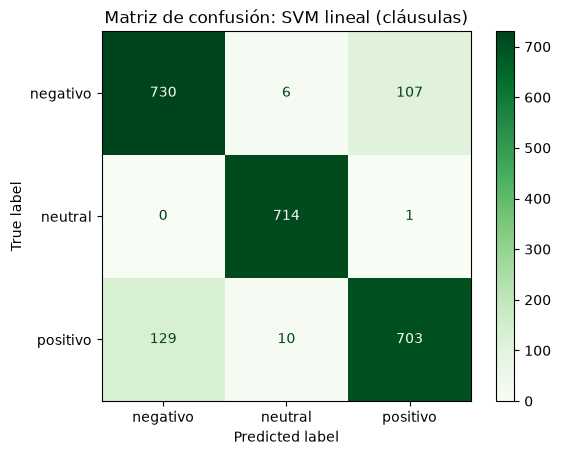

In [27]:
mejor_clausulas = grid_clausulas.best_estimator_

y_pred_clausulas = mejor_clausulas.predict(X_val)

print(f"Accuracy en validación: {accuracy_score(y_val, y_pred_clausulas):.4f}\n")
print(classification_report(y_val, y_pred_clausulas, digits=4))

ConfusionMatrixDisplay.from_predictions(y_val, y_pred_clausulas, cmap="Greens")
plt.title("Matriz de confusión: SVM lineal (cláusulas)")
plt.show()

### 15.1. Resultados de la representación por cláusulas

El modelo con cláusulas obtuvo 88,66% de accuracy promedio en validación cruzada con `C=0.3`, frente a 88,30% del modelo con conectores por oraciones. La mejora es pequeña, pero se repite en las cinco particiones: en cuatro mejora entre 0,31 y 0,63 puntos y en la quinta empata.

En validación pasa de 88,71% a 89,46%. Por clase, los F1-scores de `negativo` y `positivo` suben a 0,86 y 0,85 (antes 0,85 y 0,84) y `neutral` se mantiene en 0,99, es decir, la mejora está en la confusión entre positivo y negativo, que era el objetivo.

En el conjunto de evaluación de Kaggle el modelo cambia la predicción en 101 de las 3.000 reseñas respecto al modelo de conectores por oraciones.

## 16. Entrenamiento y almacenamiento del modelo con cláusulas

Entrenamos el pipeline con cláusulas con las 12.000 reseñas, lo guardamos con `joblib` sin sobrescribir los modelos anteriores, comprobamos que el archivo cargado da las mismas predicciones y generamos su archivo para Kaggle con la misma función de la sección 12.

In [28]:
modelo_svm_clausulas = clone(mejor_clausulas)
modelo_svm_clausulas.fit(X, y)

ruta_svm_clausulas = carpeta_modelos / "svm_lineal_clausulas.joblib"
joblib.dump(modelo_svm_clausulas, ruta_svm_clausulas)

modelo_clausulas_cargado = joblib.load(ruta_svm_clausulas)

assert np.array_equal(
    modelo_svm_clausulas.predict(X.iloc[:50]),
    modelo_clausulas_cargado.predict(X.iloc[:50])
)

print("Modelo guardado y verificado:", ruta_svm_clausulas)

submission_clausulas = generar_submission(modelo_clausulas_cargado, "submission_svm_lineal_clausulas.csv")

cambios = (submission_clausulas["answer"] != submission_svm["answer"]).sum()
print(f"Reseñas de evaluación en las que cambia la predicción frente al modelo de conectores: {cambios}")

Modelo guardado y verificado: C:\Users\User\Documents\ML\Proyecto-Machine-Learning\models\svm_lineal_clausulas.joblib
Archivo: submission_svm_lineal_clausulas.csv
answer
positivo    1080
negativo    1060
neutral      860 

Reseñas de evaluación en las que cambia la predicción frente al modelo de conectores: 101


## 17. Evaluación en Kaggle del modelo con cláusulas

| Envío | Modelo | Accuracy CV | Accuracy validación | Puntaje público Kaggle |
|---|---|---|---|---|
| `submission_svm_lineal_conectores.csv` | SVM lineal, conectores por oraciones | 88,30% | 88,71% | 87,56% |
| `submission_svm_lineal_clausulas.csv` | SVM lineal, conectores por cláusulas | 88,66% | 89,46% | 88,33% |

El modelo con cláusulas obtuvo un puntaje público de 88,33%, 0,78 puntos más que el modelo con conectores por oraciones (87,56%). Es el mejor resultado del equipo en Kaggle.

La mejora en Kaggle es parecida a la que se vio en validación (de 88,71% a 89,46%), y el puntaje público vuelve a quedar un poco por debajo de la validación cruzada y de la validación, como pasó con el modelo anterior. Como la mejora aparece en las cinco particiones de la validación cruzada, en la validación y en Kaggle, este es el modelo que proponemos para la entrega en Bloque Neón: `svm_lineal_clausulas.joblib`.

## 18. Conclusiones

Desarrollamos un clasificador de sentimientos con SVM lineal (`LinearSVC`), con la misma partición y validación cruzada que usa el equipo.

Primero cambiamos la Regresión Logística del modelo V2 por una SVM lineal, con la misma representación (última oración con TF-IDF de palabras y caracteres). Con `C=0.2` obtuvo 85,95% en validación cruzada y 87,29% en validación. La ponderación de clases no cambió los resultados, porque el desbalance del conjunto es leve.

El análisis de errores mostró que la confusión entre positivo y negativo se concentra en reseñas con dos opiniones opuestas, donde importa mucho el conector con el que empieza cada opinión. Con esa idea construimos una representación que marca cada palabra con el inicio de su frase y con la posición de la frase, y la combinamos con el TF-IDF del texto completo y la representación V2. Este modelo obtuvo 88,30% en validación cruzada, 88,71% en validación y 87,56% en el puntaje público de Kaggle, el mejor resultado del equipo en ese momento.

Después analizamos las reseñas con opiniones opuestas por cláusulas. Encontramos que conectores como "aun así", "al final" o "pero" indican casi siempre qué opinión manda, mientras que con "por otro lado", "por cierto" o "de paso" cada opinión gana más o menos la mitad de las veces. Al calcular los conectores por cláusulas, y no por oraciones, el modelo subió a 88,66% en validación cruzada, 89,46% en validación y 88,33% en el puntaje público de Kaggle, con mejoras en las cinco particiones. Este es el mejor envío del equipo y el modelo propuesto para la entrega.

Todos los pipelines se guardaron con `joblib` en la carpeta `models` y necesitan el módulo `transformaciones.py` para cargarse. Para la entrega en Bloque Neón se debe usar el modelo del envío con mejor puntaje en Kaggle.

Como limitaciones, los modelos con conectores alcanzan casi el 100% de accuracy en entrenamiento, lo que muestra que memorizan bastante. Además, en las reseñas cuyo conector no indica cuál opinión es la principal, una representación basada en palabras no tiene cómo decidir, y esos casos ponen un límite a la accuracy alcanzable. Esto se podría abordar en la segunda parte del proyecto con modelos secuenciales.

## 19. Segundo intento: ponderación de los bloques del SVM por cláusulas

El mejor SVM por cláusulas combina cuatro bloques dentro de un `FeatureUnion`:

1. La reseña marcada por cláusulas y posición.
2. TF-IDF de palabras del texto completo.
3. TF-IDF de palabras de la última oración.
4. TF-IDF de caracteres de la última oración.

Hasta ahora los cuatro bloques tienen el mismo peso. Sin embargo, el análisis previo mostró que la información de cláusulas y de la última oración es especialmente útil para resolver reseñas con opiniones opuestas. En este experimento se modifica la **ponderación relativa** de los bloques sin cambiar sus características.

La rama interna todavía se llama `conectores` porque proviene de la representación anterior, aunque en el modelo ganador esa rama ya utiliza `marcar_clausulas_lote`.

Se prueban perfiles de pesos dirigidos: aumentar la importancia de las cláusulas, reducir ligeramente el texto completo y, en algunos perfiles, reforzar también la última oración. El hiperparámetro `C` se vuelve a ajustar porque cambiar la escala relativa de las características puede modificar la regularización óptima.


In [29]:
# Perfiles de pesos dirigidos.
# "conectores" corresponde a la rama que, en representacion_clausulas,
# ya fue reemplazada por marcar_clausulas_lote.

pesos_base = {
    "conectores": 1.0,
    "texto_completo": 1.0,
    "ultima_palabras": 1.0,
    "ultima_caracteres": 1.0
}

perfiles_pesos = [
    pesos_base,

    # Dar más importancia únicamente a las cláusulas
    {
        "conectores": 1.25,
        "texto_completo": 1.0,
        "ultima_palabras": 1.0,
        "ultima_caracteres": 1.0
    },
    {
        "conectores": 1.50,
        "texto_completo": 1.0,
        "ultima_palabras": 1.0,
        "ultima_caracteres": 1.0
    },
    {
        "conectores": 2.00,
        "texto_completo": 1.0,
        "ultima_palabras": 1.0,
        "ultima_caracteres": 1.0
    },

    # Más cláusulas y menos texto completo
    {
        "conectores": 1.50,
        "texto_completo": 0.75,
        "ultima_palabras": 1.0,
        "ultima_caracteres": 1.0
    },

    # Reforzar cláusulas y la última oración
    {
        "conectores": 1.50,
        "texto_completo": 1.0,
        "ultima_palabras": 1.25,
        "ultima_caracteres": 1.25
    },

    # Perfil más agresivo: cláusulas + última oración, reduciendo texto completo
    {
        "conectores": 1.75,
        "texto_completo": 0.75,
        "ultima_palabras": 1.25,
        "ultima_caracteres": 1.25
    }
]

pipeline_svm_pesos = Pipeline([
    ("representacion", clone(representacion_clausulas)),
    ("modelo", LinearSVC(max_iter=5000, random_state=42))
])

param_grid_pesos = {
    "representacion__transformer_weights": perfiles_pesos,
    "modelo__C": [0.15, 0.30, 0.45]
}

grid_pesos = GridSearchCV(
    estimator=pipeline_svm_pesos,
    param_grid=param_grid_pesos,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=False
)

grid_pesos.fit(X_train, y_train)

print("Mejores parámetros:")
print(grid_pesos.best_params_)
print(f"\nAccuracy promedio en CV: {grid_pesos.best_score_:.4f}")
print(f"Referencia SVM por cláusulas: {grid_clausulas.best_score_:.4f}")
print(
    "Diferencia CV (puntos):",
    round((grid_pesos.best_score_ - grid_clausulas.best_score_) * 100, 3)
)


Fitting 5 folds for each of 21 candidates, totalling 105 fits
Mejores parámetros:
{'modelo__C': 0.15, 'representacion__transformer_weights': {'conectores': 1.5, 'texto_completo': 1.0, 'ultima_palabras': 1.0, 'ultima_caracteres': 1.0}}

Accuracy promedio en CV: 0.8879
Referencia SVM por cláusulas: 0.8866
Diferencia CV (puntos): 0.135


### 19.1. Resultados de la búsqueda

Además del mejor promedio, se muestran los diez perfiles con mayor accuracy. Esto permite verificar si la mejora depende de una combinación aislada o si existe una tendencia consistente al modificar los pesos.


In [30]:
resultados_pesos = pd.DataFrame(grid_pesos.cv_results_)

tabla_pesos = pd.DataFrame({
    "C": resultados_pesos["param_modelo__C"].astype(float),
    "pesos": resultados_pesos["param_representacion__transformer_weights"],
    "CV media": resultados_pesos["mean_test_score"],
    "CV std": resultados_pesos["std_test_score"],
    "ranking": resultados_pesos["rank_test_score"]
}).sort_values(["ranking", "CV media"], ascending=[True, False])

display(tabla_pesos.head(10).reset_index(drop=True))


,C,pesos,CV media,CV std,ranking
0,0.15,"{'conectores': 1.5, 'texto_completo': 1.0, 'ultima_palabras': 1.0, 'ultima_caracteres': 1.0}",0.887917,0.013471,1
1,0.15,"{'conectores': 1.25, 'texto_completo': 1.0, 'ultima_palabras': 1.0, 'ultima_caracteres': 1.0}",0.887604,0.012278,2
2,0.30,"{'conectores': 1.25, 'texto_completo': 1.0, 'ultima_palabras': 1.0, 'ultima_caracteres': 1.0}",0.887083,0.012708,3
3,0.15,"{'conectores': 1.5, 'texto_completo': 1.0, 'ultima_palabras': 1.25, 'ultima_caracteres': 1.25}",0.886979,0.012294,4
4,0.15,"{'conectores': 1.75, 'texto_completo': 0.75, 'ultima_palabras': 1.25, 'ultima_caracteres': 1.25}",0.886771,0.011490,5
5,0.30,"{'conectores': 1.5, 'texto_completo': 1.0, 'ultima_palabras': 1.0, 'ultima_caracteres': 1.0}",0.886771,0.011751,6
6,0.30,"{'conectores': 1.0, 'texto_completo': 1.0, 'ultima_palabras': 1.0, 'ultima_caracteres': 1.0}",0.886562,0.013341,7
7,0.30,"{'conectores': 1.5, 'texto_completo': 0.75, 'ultima_palabras': 1.0, 'ultima_caracteres': 1.0}",0.886354,0.011207,8
8,0.30,"{'conectores': 1.75, 'texto_completo': 0.75, 'ultima_palabras': 1.25, 'ultima_caracteres': 1.25}",0.886250,0.010498,9
9,0.45,"{'conectores': 1.25, 'texto_completo': 1.0, 'ultima_palabras': 1.0, 'ultima_caracteres': 1.0}",0.886146,0.011966,10


### 19.2. Comparación partición por partición

Como el SVM por cláusulas original obtuvo su mejor resultado con `C=0.3` y pesos iguales, ese candidato está incluido explícitamente en la nueva búsqueda. Se compara con el mejor perfil ponderado usando exactamente las mismas cinco particiones.


In [31]:
# Localizar el candidato de referencia: C=0.3 y todos los pesos iguales a 1
indice_base_pesos = None

for i, params in enumerate(grid_pesos.cv_results_["params"]):
    if (
        np.isclose(params["modelo__C"], 0.30)
        and params["representacion__transformer_weights"] == pesos_base
    ):
        indice_base_pesos = i
        break

assert indice_base_pesos is not None, "No se encontró el perfil base en la búsqueda."

indice_mejor_pesos = grid_pesos.best_index_

comparacion_particiones_pesos = pd.DataFrame({
    "Cláusulas sin ponderación": [
        grid_pesos.cv_results_[f"split{k}_test_score"][indice_base_pesos]
        for k in range(5)
    ],
    "Mejor ponderación": [
        grid_pesos.cv_results_[f"split{k}_test_score"][indice_mejor_pesos]
        for k in range(5)
    ]
}, index=[f"Partición {k + 1}" for k in range(5)])

comparacion_particiones_pesos["Diferencia (puntos)"] = (
    comparacion_particiones_pesos["Mejor ponderación"]
    - comparacion_particiones_pesos["Cláusulas sin ponderación"]
) * 100

display(comparacion_particiones_pesos.round(4))


,Cláusulas sin ponderación,Mejor ponderación,Diferencia (puntos)
Partición 1,0.8938,0.8922,-0.1563
Partición 2,0.8729,0.8797,0.6771
Partición 3,0.9010,0.9036,0.2604
Partición 4,0.8969,0.8979,0.1042
Partición 5,0.8682,0.8661,-0.2083


### 19.3. Evaluación final en validación

El conjunto de validación se utiliza únicamente después de haber seleccionado los pesos y `C` mediante validación cruzada sobre `X_train`. La referencia a superar es el SVM por cláusulas: **88,66% en CV** y **89,46% en validación**.


,Modelo,Accuracy CV,Accuracy validación
0,SVM por cláusulas,0.8866,0.8946
1,SVM cláusulas + ponderación de bloques,0.8879,0.8954



Reporte de clasificación del modelo ponderado:

              precision    recall  f1-score   support

    negativo     0.8510    0.8671    0.8590       843
     neutral     0.9781    0.9986    0.9882       715
    positivo     0.8681    0.8361    0.8518       842

    accuracy                         0.8954      2400
   macro avg     0.8990    0.9006    0.8997      2400
weighted avg     0.8948    0.8954    0.8950      2400



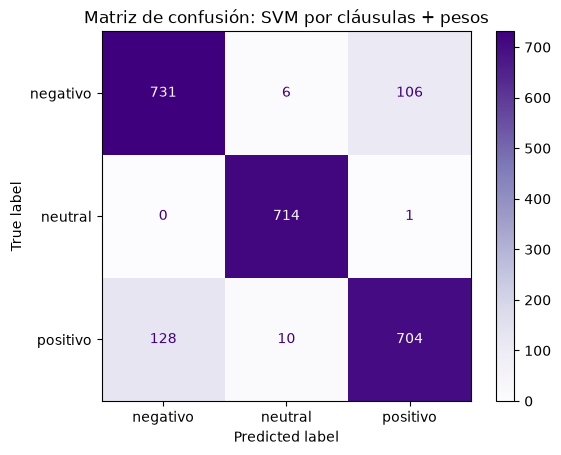

In [32]:
mejor_pesos = grid_pesos.best_estimator_
y_pred_pesos = mejor_pesos.predict(X_val)

acc_pesos = accuracy_score(y_val, y_pred_pesos)
acc_clausulas = accuracy_score(y_val, y_pred_clausulas)

comparacion_validacion_pesos = pd.DataFrame([
    {
        "Modelo": "SVM por cláusulas",
        "Accuracy CV": grid_clausulas.best_score_,
        "Accuracy validación": acc_clausulas
    },
    {
        "Modelo": "SVM cláusulas + ponderación de bloques",
        "Accuracy CV": grid_pesos.best_score_,
        "Accuracy validación": acc_pesos
    }
])

display(comparacion_validacion_pesos.round(4))

print("\nReporte de clasificación del modelo ponderado:\n")
print(classification_report(y_val, y_pred_pesos, digits=4))

ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_pred_pesos,
    cmap="Purples"
)
plt.title("Matriz de confusión: SVM por cláusulas + pesos")
plt.show()


### 19.4. Modelo final y CSV de Kaggle

Esta celda entrena la mejor configuración ponderada con las 12.000 reseñas, guarda el modelo y genera el CSV. El archivo puede generarse aunque luego se decida no subirlo; la decisión de enviarlo a Kaggle debe basarse en la comparación de CV y validación de la sección anterior.


In [33]:
modelo_svm_pesos = clone(mejor_pesos)
modelo_svm_pesos.fit(X, y)

ruta_svm_pesos = carpeta_modelos / "svm_clausulas_pesos.joblib"
joblib.dump(modelo_svm_pesos, ruta_svm_pesos)

modelo_pesos_cargado = joblib.load(ruta_svm_pesos)

assert np.array_equal(
    modelo_svm_pesos.predict(X.iloc[:50]),
    modelo_pesos_cargado.predict(X.iloc[:50])
)

submission_pesos = generar_submission(
    modelo_pesos_cargado,
    "submission_svm_clausulas_pesos.csv"
)

cambios_vs_clausulas = (
    submission_pesos["answer"] != submission_clausulas["answer"]
).sum()

print("Modelo guardado y verificado:", ruta_svm_pesos)
print(
    "Predicciones distintas frente al SVM por cláusulas:",
    cambios_vs_clausulas,
    "de",
    len(submission_pesos)
)


Archivo: submission_svm_clausulas_pesos.csv
answer
positivo    1077
negativo    1059
neutral      864 

Modelo guardado y verificado: C:\Users\User\Documents\ML\Proyecto-Machine-Learning\models\svm_clausulas_pesos.joblib
Predicciones distintas frente al SVM por cláusulas: 53 de 3000


### 19.5. Interpretación

Complete esta sección con los valores reales después de ejecutar el experimento. Para considerar que la ponderación aporta una mejora convincente, lo ideal es que supere al modelo por cláusulas en CV y que la validación no retroceda. También es útil revisar si la mejora aparece en varias particiones y no únicamente en una.
